In [1]:
import os
import sys
from pathlib import Path

import hydra
import rootutils

# Setup root directory
rootutils.setup_root(__file__ if "__file__" in dir() else os.getcwd(), indicator=".project-root", pythonpath=True)

import torch
import torchvision
from torchvision.transforms import v2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from torchmetrics.classification import MulticlassConfusionMatrix
from omegaconf import OmegaConf

# Import data components
from src.data.components.transform_subset import TransformSubset

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

/home/lukasb/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Model Evaluation Script

This notebook provides comprehensive evaluation tools for models trained with `train.py`:
- Confusion matrices with visualizations
- Per-class metrics (precision, recall, F1-score)
- Per-class loss analysis
- Misclassification analysis
- Comparative analysis across runs

## Configuration

Set the path to your experiment results and configure evaluation parameters.

In [2]:
# Configuration
MODEL_PATH = "../logs/train/SurfaceDefectDetection/full_cleaned/2026-02-05_01-00-29_new_ce"  # Change to your experiment path
EVAL_PATH = "../logs/eval/SurfaceDefectDetection/full_cleaned_new_ce"
CONFIG_PATH = "../configs"  # Path to your configs directory
CONFIG_NAME = "train.yaml"  # Config file used for training

# Device configuration
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


## Load Configuration and Data

Load the training configuration and setup data transformations.

In [3]:
test_data_path = "/srv/defectDetectionDataset/multiclassClassification/full_clean_clustered_new/test"

test_dataset = torchvision.datasets.ImageFolder(root=test_data_path)

class_names = test_dataset.classes
num_classes = len(class_names)

print(f"\nNumber of classes: {num_classes}")
print(f"Class names: {class_names}")

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Test transforms (same as training)
test_transforms = v2.Compose(
    [
        v2.Resize(480, antialias=True),
        v2.CenterCrop(480),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=mean, std=std),
    ])


Number of classes: 9
Class names: ['black_stain', 'corrosion', 'crack', 'deformation', 'missing_part', 'no_defects', 'other', 'silicate_stain', 'water_stain']


In [4]:
# Load configuration
with hydra.initialize(version_base="1.3", config_path=CONFIG_PATH):
    cfg = hydra.compose(config_name=CONFIG_NAME)

# Load hyperparameters if available
hyperparams_path = Path(MODEL_PATH) / "summary" / "hyperparameters.yaml"
if hyperparams_path.exists():
    hyperparams = OmegaConf.load(hyperparams_path)
    print("Loaded hyperparameters from experiment")
else:
    hyperparams = cfg
    print("Using default config (hyperparameters.yaml not found)")

print(hyperparams)

Loaded hyperparameters from experiment
{'research_name': 'SurfaceDefectDetection', 'run_name_postfix': 'new_ce', 'run_name': '2026-02-05_01-00-29_new_ce', 'log_path': './logs', 'seed': 42, 'n_runs': 5, 'paths': {'root_dir': '.', 'log_dir': './logs/', 'output_dir': '/home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/full_cleaned/2026-02-05_01-00-29_new_ce', 'work_dir': '/home/lukasb/Documents/NoisyLabelDefectDetection'}, 'trainer': {'_target_': 'lightning.pytorch.trainer.Trainer', 'default_root_dir': '/home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/full_cleaned/2026-02-05_01-00-29_new_ce', 'min_epochs': 10, 'max_epochs': 200, 'accelerator': 'gpu', 'devices': [0], 'check_val_every_n_epoch': 1, 'deterministic': False, 'precision': '16-mixed'}, 'callbacks': {'model_checkpoint': {'_target_': 'lightning.pytorch.callbacks.ModelCheckpoint', 'dirpath': None, 'filename': 'epoch_{epoch:03d}-val_f1_{val/f1_macro:.4f}', 'monitor': '

## Load Best Model

Load the best model checkpoint from a specific run.

In [5]:
def load_model():
    """Load the best model from a specific run."""
    model = hydra.utils.instantiate(hyperparams.model, num_classes=num_classes)
    checkpoint_path = Path("../logs/train/SurfaceDefectDetection/full_cleaned/2026-02-05_01-00-29_new_ce/run_5/checkpoints/epoch_073-val_f1_0.7669.ckpt")
    
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Model not found at {checkpoint_path}")
    
    ckpt = torch.load(checkpoint_path, map_location="cpu")
    state = ckpt["state_dict"] if "state_dict" in ckpt else ckpt
    
    model.load_state_dict(state, strict=True)
    model.to(device)
    model.eval()
    
    print(f"Loaded model from: {checkpoint_path}")
    return model

model = load_model()

Loaded model from: ../logs/train/SurfaceDefectDetection/full_cleaned/2026-02-05_01-00-29_new_ce/run_5/checkpoints/epoch_073-val_f1_0.7669.ckpt


## Generate Predictions on Test Set

Run inference on the test set and collect predictions, targets, and logits.

In [6]:
def get_predictions(model, dataloader, device):
    """Generate predictions and collect all outputs."""
    all_preds = []
    all_targets = []
    all_logits = []
    all_probs = []
    
    model.eval()
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            
            all_logits.append(outputs.cpu())
            all_probs.append(probs.cpu())
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())
    
    return {
        'predictions': torch.cat(all_preds).numpy(),
        'targets': torch.cat(all_targets).numpy(),
        'logits': torch.cat(all_logits).numpy(),
        'probabilities': torch.cat(all_probs).numpy()
    }

# Create test dataloader
test_dataset_transformed = TransformSubset(
    test_dataset,
    indices=list(range(len(test_dataset))),
    transform=test_transforms
)

test_loader = torch.utils.data.DataLoader(
    test_dataset_transformed,
    batch_size=hyperparams.data.get("batch_size", 32),
    shuffle=False,
    num_workers=4
)

# Get predictions
print("Generating predictions on test set...")
results = get_predictions(model, test_loader, device)
print(f"Generated predictions for {len(results['predictions'])} samples")


Generating predictions on test set...
Generated predictions for 967 samples


## Confusion Matrix Visualization

Generate and visualize confusion matrices to understand classification patterns.

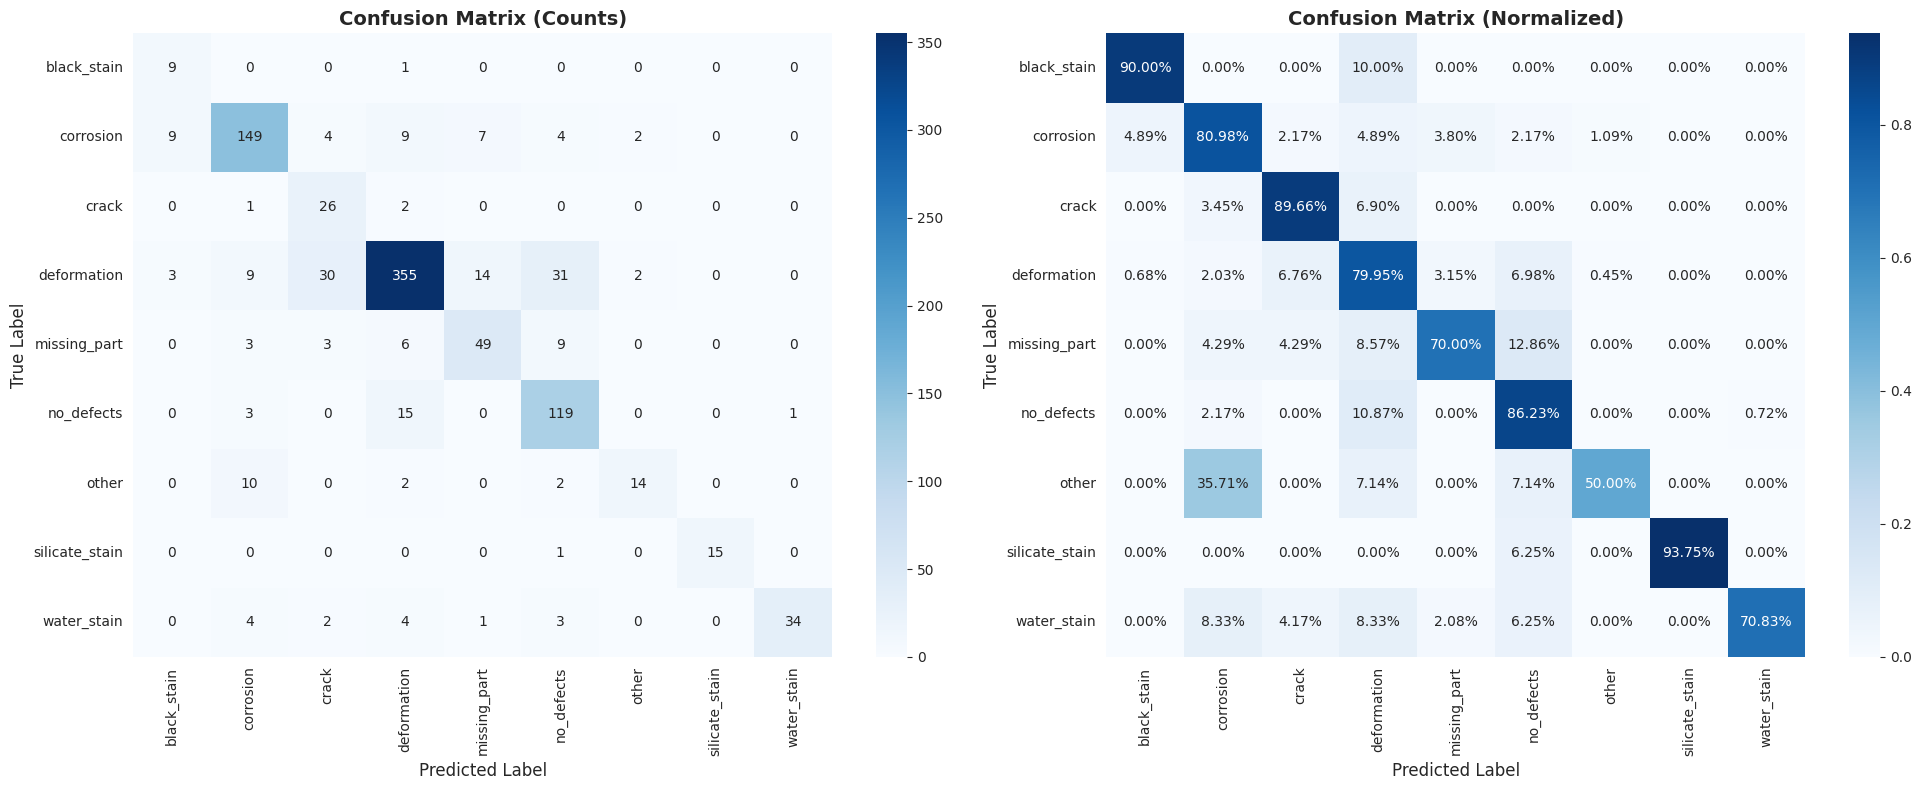

Saved confusion matrix to ../logs/eval/SurfaceDefectDetection/full_cleaned_new_ce/confusion_matrix.png


In [7]:
# Compute confusion matrix
cm = confusion_matrix(results['targets'], results['predictions'])

# Normalize confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot confusion matrix (counts)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Confusion matrix with counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=ax1)
ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=12)
ax1.set_ylabel('True Label', fontsize=12)

# Confusion matrix with percentages
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax2)
ax2.set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=12)
ax2.set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

# Save confusion matrix
save_path = Path(EVAL_PATH) / "confusion_matrix.png"
save_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved confusion matrix to {save_path}")

## Per-Class Metrics

Compute and visualize per-class precision, recall, and F1-score.

Classification Report:
                precision    recall  f1-score     support
black_stain      0.428571  0.900000  0.580645   10.000000
corrosion        0.832402  0.809783  0.820937  184.000000
crack            0.400000  0.896552  0.553191   29.000000
deformation      0.901015  0.799550  0.847255  444.000000
missing_part     0.690141  0.700000  0.695035   70.000000
no_defects       0.704142  0.862319  0.775244  138.000000
other            0.777778  0.500000  0.608696   28.000000
silicate_stain   1.000000  0.937500  0.967742   16.000000
water_stain      0.971429  0.708333  0.819277   48.000000
accuracy         0.796277  0.796277  0.796277    0.796277
macro avg        0.745053  0.790448  0.740891  967.000000
weighted avg     0.826253  0.796277  0.803073  967.000000
Macro precission: 0.75608841626521
Macro recall: 0.7914198998849442
Macro f1: 0.7506887254061838


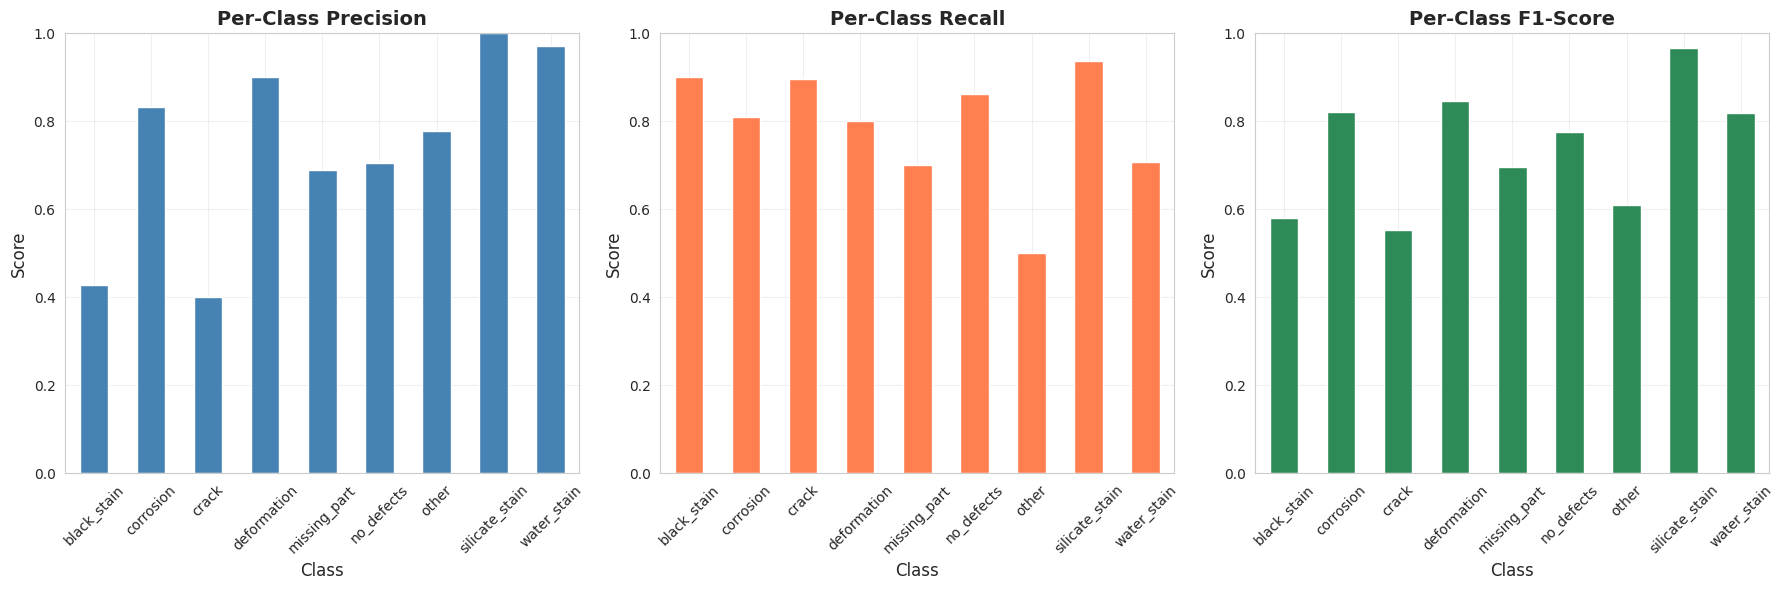

Saved per-class metrics to ../logs/eval/SurfaceDefectDetection/full_cleaned_new_ce/per_class_metrics.png
Saved classification report to ../logs/eval/SurfaceDefectDetection/full_cleaned_new_ce/classification_report.csv


In [8]:
# Generate classification report
report = classification_report(
    results['targets'], 
    results['predictions'], 
    target_names=class_names,
    output_dict=True
)

# Convert to DataFrame for better visualization
report_df = pd.DataFrame(report).transpose()

# Display the report
print("Classification Report:")
print(report_df)

print(f"Macro precission: {report_df['precision'].mean()}")
print(f"Macro recall: {report_df['recall'].mean()}")
print(f"Macro f1: {report_df['f1-score'].mean()}")


# Plot per-class metrics
metrics_df = report_df.iloc[:-3]  # Exclude accuracy, macro avg, weighted avg
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Precision
metrics_df['precision'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Per-Class Precision', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Recall
metrics_df['recall'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Per-Class Recall', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylim([0, 1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# F1-Score
metrics_df['f1-score'].plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Per-Class F1-Score', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Score', fontsize=12)
axes[2].set_xlabel('Class', fontsize=12)
axes[2].set_ylim([0, 1])
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save metrics
save_path = Path(EVAL_PATH) / "per_class_metrics.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved per-class metrics to {save_path}")

# Save classification report
report_path = Path(EVAL_PATH) / "classification_report.csv"
report_df.to_csv(report_path)
print(f"Saved classification report to {report_path}")

## Misclassification Analysis

Identify and analyze the most common misclassifications.

Total misclassified samples: 197 / 967 (20.37%)

Top 10 Most Common Misclassifications:
  true_class predicted_class  count
 deformation      no_defects     31
 deformation           crack     30
  no_defects     deformation     15
 deformation    missing_part     14
       other       corrosion     10
 deformation       corrosion      9
   corrosion     black_stain      9
   corrosion     deformation      9
missing_part      no_defects      9
   corrosion    missing_part      7


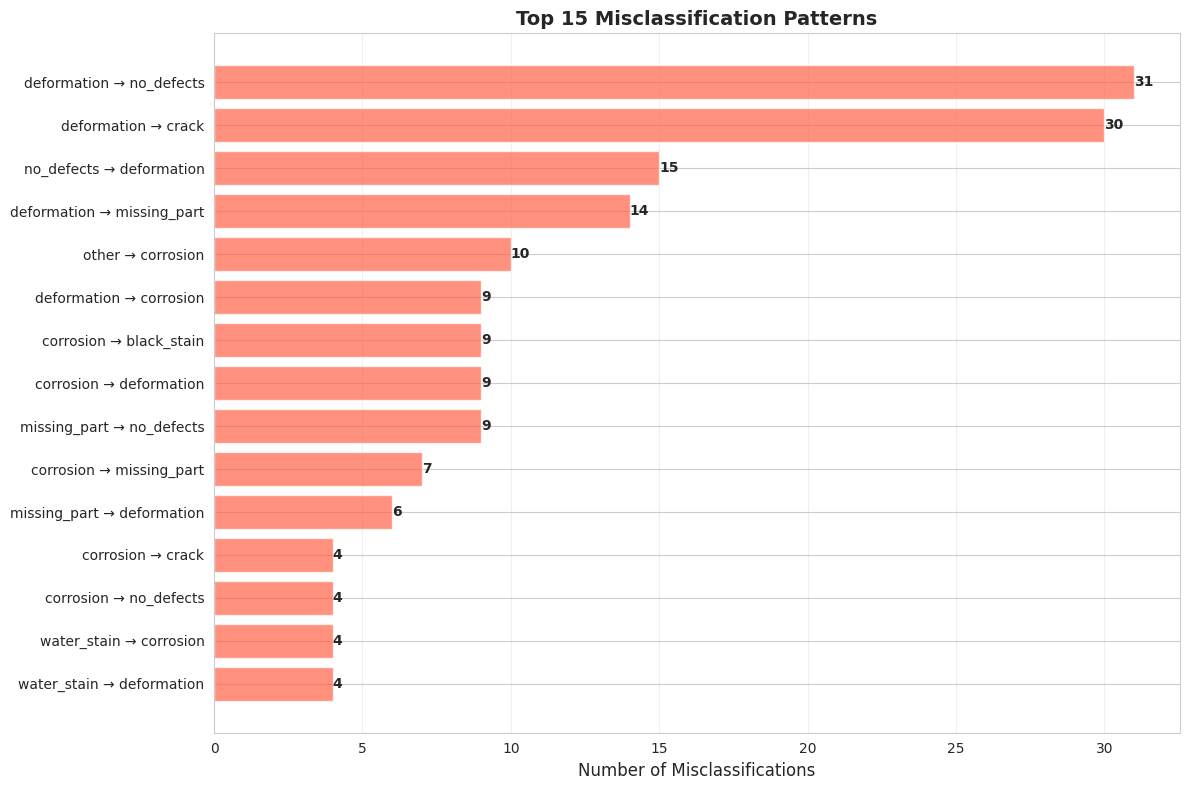


Saved misclassification patterns to ../logs/eval/SurfaceDefectDetection/full_cleaned_new_ce/misclassification_patterns.png
Saved detailed misclassification data to ../logs/eval/SurfaceDefectDetection/full_cleaned_new_ce/misclassifications.csv


In [9]:
# Find misclassified samples
misclassified_mask = results['predictions'] != results['targets']
misclassified_indices = np.where(misclassified_mask)[0]

print(f"Total misclassified samples: {len(misclassified_indices)} / {len(results['targets'])} ({100*len(misclassified_indices)/len(results['targets']):.2f}%)")

# Analyze misclassification patterns
misclassification_pairs = []
for idx in misclassified_indices:
    true_class = results['targets'][idx]
    pred_class = results['predictions'][idx]
    confidence = results['probabilities'][idx][pred_class]
    
    misclassification_pairs.append({
        'sample_idx': idx,
        'true_class': class_names[true_class],
        'predicted_class': class_names[pred_class],
        'confidence': confidence,
        'true_class_prob': results['probabilities'][idx][true_class]
    })

misclass_df = pd.DataFrame(misclassification_pairs)

# Count most common misclassification pairs
misclass_counts = misclass_df.groupby(['true_class', 'predicted_class']).size().reset_index(name='count')
misclass_counts = misclass_counts.sort_values('count', ascending=False)

print("\nTop 10 Most Common Misclassifications:")
print(misclass_counts.head(10).to_string(index=False))

# Visualize misclassification patterns
top_n = min(15, len(misclass_counts))
top_misclass = misclass_counts.head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(top_misclass))
bars = ax.barh(y_pos, top_misclass['count'], color='tomato', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row['true_class']} → {row['predicted_class']}" 
                     for _, row in top_misclass.iterrows()])
ax.invert_yaxis()
ax.set_xlabel('Number of Misclassifications', fontsize=12)
ax.set_title(f'Top {top_n} Misclassification Patterns', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{int(width)}',
            ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Save misclassification analysis
save_path = Path(EVAL_PATH) / "misclassification_patterns.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\nSaved misclassification patterns to {save_path}")

misclass_csv_path = Path(EVAL_PATH) / "misclassifications.csv"
misclass_df.to_csv(misclass_csv_path, index=False)
print(f"Saved detailed misclassification data to {misclass_csv_path}")

## Confidence Distribution Analysis

Analyze prediction confidence for correct vs incorrect predictions.

/tmp/ipykernel_2065729/1394116183.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=['Correct', 'Incorrect'], patch_artist=True)


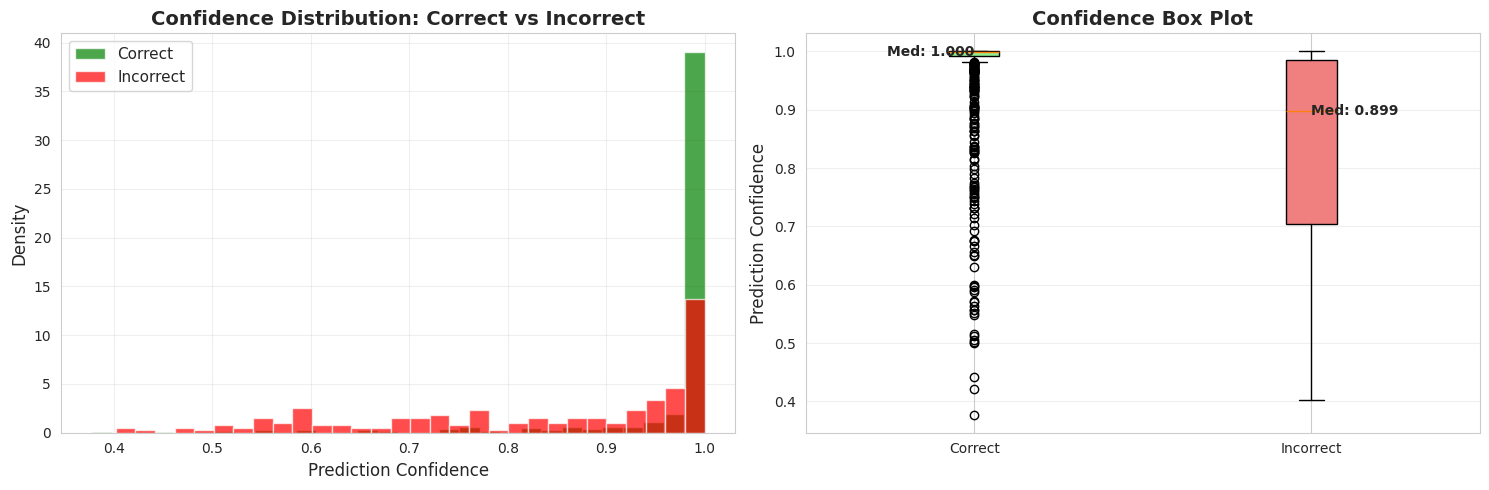

Saved confidence distribution to ../logs/eval/SurfaceDefectDetection/full_cleaned_new_ce/confidence_distribution.png

Confidence Statistics:
Correct predictions - Mean: 0.966, Median: 1.000, Std: 0.094
Incorrect predictions - Mean: 0.835, Median: 0.899, Std: 0.168


In [10]:
# Get max confidence for each prediction
max_confidences = np.max(results['probabilities'], axis=1)
correct_mask = results['predictions'] == results['targets']

correct_confidences = max_confidences[correct_mask]
incorrect_confidences = max_confidences[~correct_mask]

# Plot confidence distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(correct_confidences, bins=30, alpha=0.7, label='Correct', color='green', density=True)
axes[0].hist(incorrect_confidences, bins=30, alpha=0.7, label='Incorrect', color='red', density=True)
axes[0].set_xlabel('Prediction Confidence', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Confidence Distribution: Correct vs Incorrect', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Box plot
box_data = [correct_confidences, incorrect_confidences]
bp = axes[1].boxplot(box_data, labels=['Correct', 'Incorrect'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
axes[1].set_ylabel('Prediction Confidence', fontsize=12)
axes[1].set_title('Confidence Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Add statistics
axes[1].text(1, np.median(correct_confidences), f'Med: {np.median(correct_confidences):.3f}', 
             ha='right', va='center', fontsize=10, fontweight='bold')
axes[1].text(2, np.median(incorrect_confidences), f'Med: {np.median(incorrect_confidences):.3f}', 
             ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Save confidence distribution
save_path = Path(EVAL_PATH) / "confidence_distribution.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved confidence distribution to {save_path}")

# Print statistics
print(f"\nConfidence Statistics:")
print(f"Correct predictions - Mean: {correct_confidences.mean():.3f}, Median: {np.median(correct_confidences):.3f}, Std: {correct_confidences.std():.3f}")
print(f"Incorrect predictions - Mean: {incorrect_confidences.mean():.3f}, Median: {np.median(incorrect_confidences):.3f}, Std: {incorrect_confidences.std():.3f}")

## Per-Class Confidence Analysis

Analyze prediction confidence for each class separately.

Per-Class Confidence Statistics:
                    mean    median       std       min  max  count
silicate_stain  0.995494  0.999996  0.010196  0.967405  1.0   16.0
crack           0.974096  0.999998  0.080455  0.673153  1.0   29.0
no_defects      0.959022  0.999682  0.097010  0.552370  1.0  138.0
corrosion       0.954047  0.999904  0.112177  0.473311  1.0  184.0
black_stain     0.941475  0.998586  0.123767  0.590684  1.0   10.0
missing_part    0.929090  0.998416  0.124895  0.501711  1.0   70.0
deformation     0.926682  0.998477  0.135137  0.377526  1.0  444.0
water_stain     0.925237  0.999990  0.154848  0.401967  1.0   48.0
other           0.921562  0.971256  0.119144  0.598618  1.0   28.0


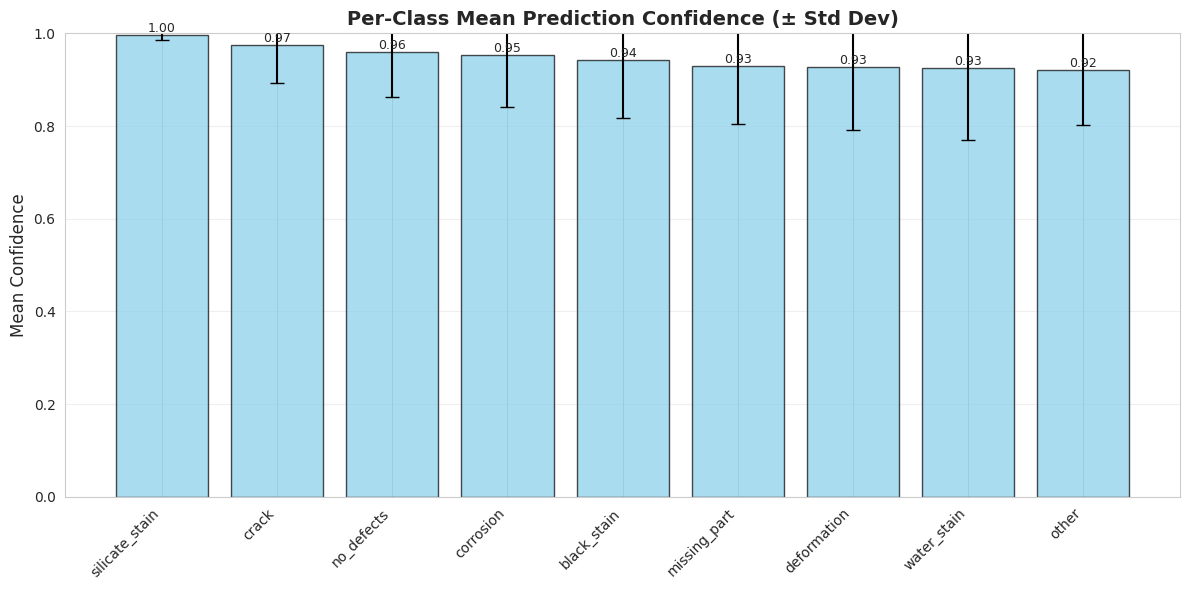


Saved per-class confidence to ../logs/eval/SurfaceDefectDetection/full_cleaned_new_ce/per_class_confidence.png
Saved per-class confidence data to ../logs/eval/SurfaceDefectDetection/full_cleaned_new_ce/per_class_confidence.csv


In [11]:
# Compute per-class confidence statistics
per_class_confidence = {}

for class_idx, class_name in enumerate(class_names):
    class_mask = results['targets'] == class_idx
    class_confidences = max_confidences[class_mask]
    
    if len(class_confidences) > 0:
        per_class_confidence[class_name] = {
            'mean': class_confidences.mean(),
            'median': np.median(class_confidences),
            'std': class_confidences.std(),
            'min': class_confidences.min(),
            'max': class_confidences.max(),
            'count': len(class_confidences)
        }

# Create DataFrame
confidence_stats_df = pd.DataFrame(per_class_confidence).T
confidence_stats_df = confidence_stats_df.sort_values('mean', ascending=False)

print("Per-Class Confidence Statistics:")
print(confidence_stats_df.to_string())

# Plot per-class mean confidence
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(confidence_stats_df))
bars = ax.bar(x_pos, confidence_stats_df['mean'], 
              yerr=confidence_stats_df['std'], 
              capsize=5, alpha=0.7, color='skyblue', edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(confidence_stats_df.index, rotation=45, ha='right')
ax.set_ylabel('Mean Confidence', fontsize=12)
ax.set_title('Per-Class Mean Prediction Confidence (± Std Dev)', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar, (idx, row)) in enumerate(zip(bars, confidence_stats_df.iterrows())):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Save per-class confidence
save_path = Path(EVAL_PATH) / "per_class_confidence.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\nSaved per-class confidence to {save_path}")

confidence_csv_path = Path(EVAL_PATH) / "per_class_confidence.csv"
confidence_stats_df.to_csv(confidence_csv_path)
print(f"Saved per-class confidence data to {confidence_csv_path}")

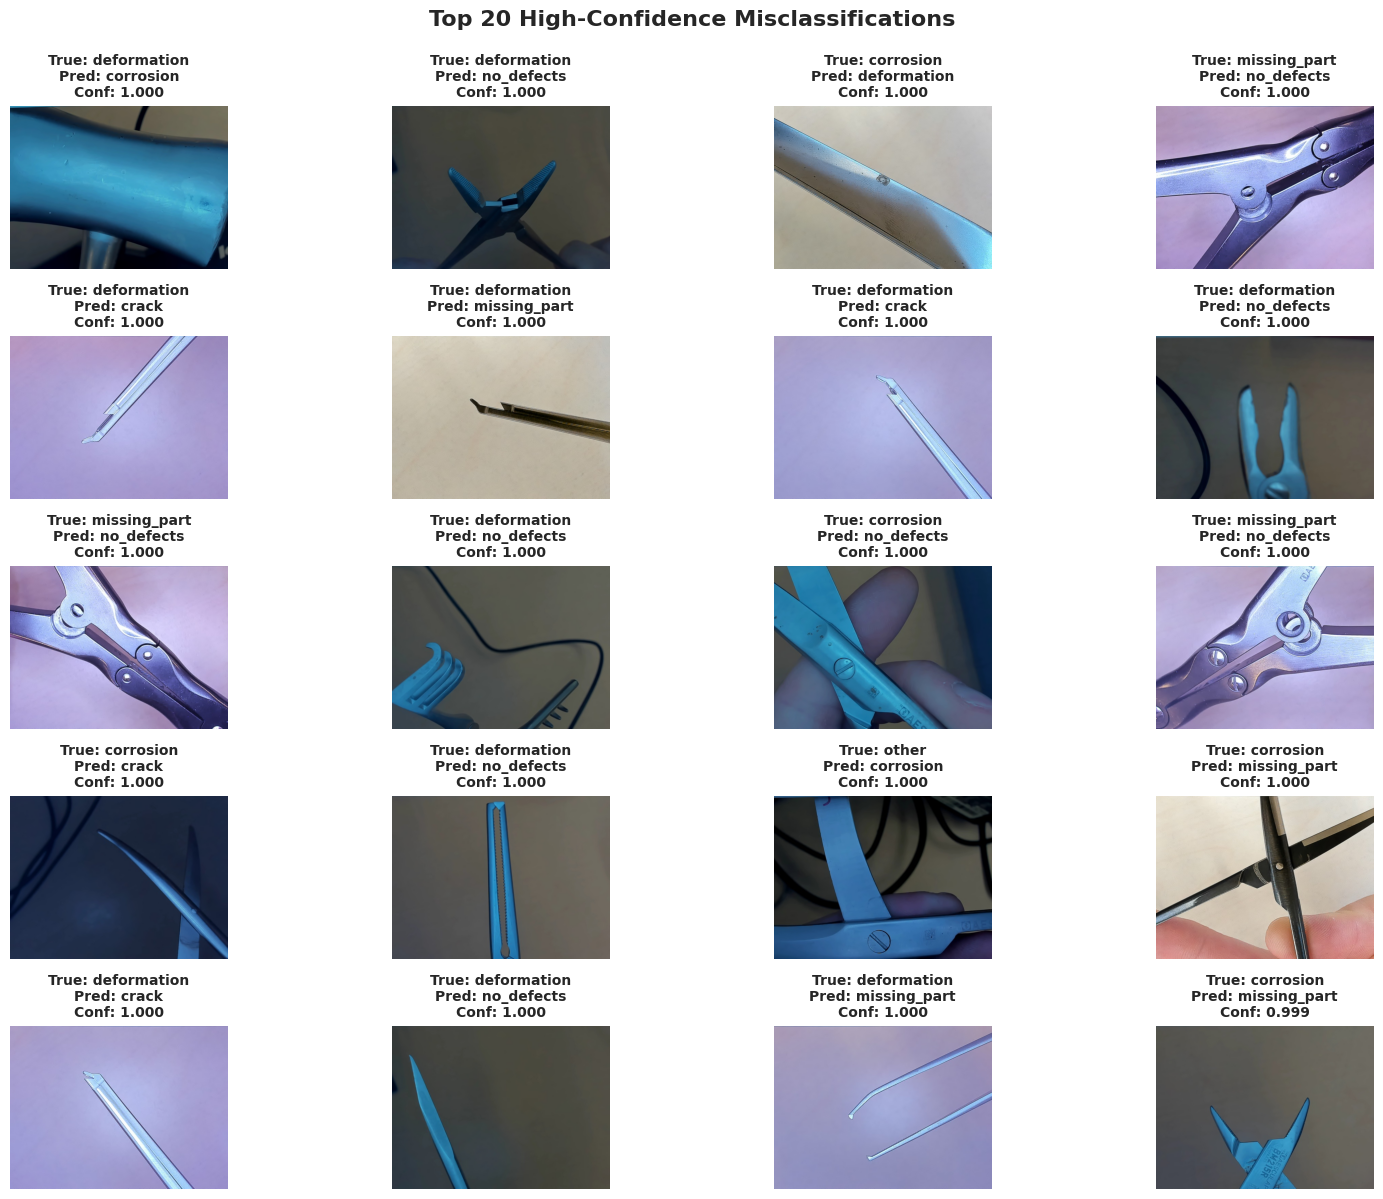


Saved high-confidence errors visualization to ../logs/eval/SurfaceDefectDetection/full_cleaned_new_ce/high_confidence_errors.png

Top 20 High-Confidence Errors:
 sample_idx   true_class predicted_class  confidence  true_class_prob
        476  deformation       corrosion    0.999999     8.822545e-07
        432  deformation      no_defects    0.999996     3.657956e-06
        173    corrosion     deformation    0.999995     2.797826e-06
        724 missing_part      no_defects    0.999977     7.707759e-09
        541  deformation           crack    0.999960     8.660733e-07
        539  deformation    missing_part    0.999947     4.654559e-05
        536  deformation           crack    0.999923     2.983198e-05
        455  deformation      no_defects    0.999906     9.426528e-05
        725 missing_part      no_defects    0.999905     3.038763e-08
        411  deformation      no_defects    0.999901     9.883357e-05
         26    corrosion      no_defects    0.999900     6.002774e-0

In [12]:
# Get high confidence incorrect predictions
high_conf_errors = misclass_df.nlargest(20, 'confidence')

# Create figure for displaying images
fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.ravel()

# Load and display images
for idx, (_, row) in enumerate(high_conf_errors.iterrows()):
    sample_idx = row['sample_idx']
    
    # Get the image path
    img_path = test_dataset.imgs[sample_idx][0]
    img = plt.imread(img_path)
    
    # Display image
    axes[idx].imshow(img)
    axes[idx].axis('off')
    
    # Create title with error information
    title = f"True: {row['true_class']}\n"
    title += f"Pred: {row['predicted_class']}\n"
    title += f"Conf: {row['confidence']:.3f}"
    axes[idx].set_title(title, fontsize=10, fontweight='bold')

plt.suptitle('Top 20 High-Confidence Misclassifications', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Save the figure
save_path = Path(EVAL_PATH) / "high_confidence_errors.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\nSaved high-confidence errors visualization to {save_path}")

# Print detailed information
print("\nTop 20 High-Confidence Errors:")
print(high_conf_errors[['sample_idx', 'true_class', 'predicted_class', 'confidence', 'true_class_prob']].to_string(index=False))